In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/BFW/faces-cropped.zip /content/

In [3]:
!unzip -q /content/faces-cropped.zip -d /content/bfw

In [4]:
faces_path = "/content/bfw"

In [5]:
image_root = "/content/bfw/Users/jrobby/bfw/bfw-cropped-aligned"

In [6]:

'''image_dict = {}

for root, dirs, files in os.walk(faces_path):

    for file in files:

        if file.endswith((".jpg", ".jpeg", ".png")):

            full_path = os.path.join(root, file)

            image_dict[file] = full_path

print("Total images found:", len(image_dict))'''

import os

image_dict = {}

for root, dirs, files in os.walk(image_root):

    for file in files:

        if file.lower().endswith(".jpg"):

            full_path = os.path.join(root, file)

            rel_path = os.path.relpath(
                full_path,
                image_root
            )

            rel_path = rel_path.replace("\\", "/")

            image_dict[rel_path] = full_path

In [7]:
print(image_dict["black_males/n009079/0055_01.jpg"])

/content/bfw/Users/jrobby/bfw/bfw-cropped-aligned/black_males/n009079/0055_01.jpg


Dataset uploaded, NOW starting Facenet512 setup


In [8]:
!ls /content/drive/MyDrive/BFW

 bfw-datatable.csv  'facenet512_similarity_results (2).csv'   faces-cropped.zip


In [9]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/BFW/bfw-datatable.csv")

print(df.head())

   fold                                 p1                                 p2  \
0     1  asian_females/n000009/0010_01.jpg  asian_females/n000009/0043_01.jpg   
1     1  asian_females/n000009/0010_01.jpg  asian_females/n000009/0120_01.jpg   
2     1  asian_females/n000009/0010_01.jpg  asian_females/n000009/0122_02.jpg   
3     1  asian_females/n000009/0010_01.jpg  asian_females/n000009/0188_01.jpg   
4     1  asian_females/n000009/0010_01.jpg  asian_females/n000009/0205_01.jpg   

   label  id1  id2           att1           att2     vgg16  resnet50  \
0      1    0    0  asian_females  asian_females  0.820039  0.703258   
1      1    0    0  asian_females  asian_females  0.719199  0.523613   
2      1    0    0  asian_females  asian_females  0.732029  0.527567   
3      1    0    0  asian_females  asian_females  0.607093  0.348211   
4      1    0    0  asian_females  asian_females  0.629153  0.384273   

    senet50  a1  a2 g1 g2 e1 e2  
0  0.679089  AF  AF  F  F  A  A  
1  0.594268 

In [10]:
import torch
from torchvision import transforms
from PIL import Image

In [11]:
!git clone https://github.com/bytedance/LVFace.git
%cd LVFace

!pip install -r requirements.txt
!pip install huggingface_hub

Cloning into 'LVFace'...
remote: Enumerating objects: 60, done.
remote: Counting objects: 100% (60/60), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 60 (delta 24), reused 48 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (60/60), 850.02 KiB | 3.21 MiB/s, done.
Resolving deltas: 100% (24/24), done.
/content/LVFace
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 84.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [12]:
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="bytedance-research/LVFace",
    filename="LVFace-B_Glint360K/LVFace-B_Glint360K.onnx"
)

print(model_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


LVFace-B_Glint360K/LVFace-B_Glint360K.on(…):   0%|          | 0.00/456M [00:00<?, ?B/s]

/root/.cache/huggingface/hub/models--bytedance-research--LVFace/snapshots/b12702ab1f5c721748e054a66dc90e1edd1f0724/LVFace-B_Glint360K/LVFace-B_Glint360K.onnx


In [13]:
!pip install onnxruntime-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 5.7 MB/s eta 0:00:00


In [14]:
from inference_onnx import LVFaceONNXInferencer

inferencer = LVFaceONNXInferencer(
    model_path=model_path,
    use_gpu=True
)

In [15]:
import inspect
from inference_onnx import LVFaceONNXInferencer

print(inspect.signature(LVFaceONNXInferencer))

(model_path: str, use_gpu: bool = True)


In [16]:
inferencer = LVFaceONNXInferencer(model_path=model_path)

print(dir(inferencer))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_preprocess_image', 'calculate_similarity', 'infer_from_image', 'infer_from_url', 'input_name', 'input_size', 'ort_session', 'output_name']


In [17]:
all_images = set(df["p1"]).union(set(df["p2"]))

print("Unique images:", len(all_images))

Unique images: 20000


In [18]:
from tqdm import tqdm
import numpy as np

embeddings = {}

for img_rel in tqdm(all_images):

    if img_rel not in image_dict:
        print("Missing:", img_rel)
        continue

    img_path = image_dict[img_rel]

    try:
        feat = inferencer.infer_from_image(img_path)

        embeddings[img_rel] = np.asarray(feat)

    except Exception as e:
        print(f"Error: {img_rel} -> {e}")

100%|██████████| 20000/20000 [04:08<00:00, 80.40it/s]


In [19]:
sample_key = list(embeddings.keys())[0]

print(sample_key)
print(embeddings[sample_key].shape)

white_females/n002595/0172_02.jpg
(1, 512)


In [21]:
from sklearn.metrics.pairwise import cosine_similarity

scores = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    img1 = row["p1"]
    img2 = row["p2"]

    if img1 not in embeddings or img2 not in embeddings:
        scores.append(np.nan)
        continue

    emb1 = embeddings[img1]
    emb2 = embeddings[img2]

    sim = cosine_similarity(emb1, emb2)[0][0]

    scores.append(sim)

df["cosine_similarity"] = scores

100%|██████████| 923898/923898 [09:03<00:00, 1701.44it/s]


In [22]:
print(df["cosine_similarity"].describe())

count    923898.000000
mean          0.124774
std           0.205380
min          -0.231666
25%          -0.006910
50%           0.035084
75%           0.127716
max           1.000000
Name: cosine_similarity, dtype: float64


In [26]:
cosine_df = df[[
    "p1",
    "p2",
    "label",
    "cosine_similarity"
]]

cosine_df.to_csv(
    "/content/lvface_cosine_similarity.csv",
    index=False
)

print("Saved!")

Saved!


In [27]:
from google.colab import files

files.download("/content/lvface_cosine_similarity.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
genuine = df[df["label"] == 1]["cosine_similarity"]
impostor = df[df["label"] == 0]["cosine_similarity"]

print("Genuine mean :", genuine.mean())
print("Impostor mean:", impostor.mean())


Genuine mean : 0.43252456
Impostor mean: 0.015238779


In [31]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    df["label"],
    df["cosine_similarity"]
)

print("ROC AUC =", auc)

ROC AUC = 0.9610637056122426


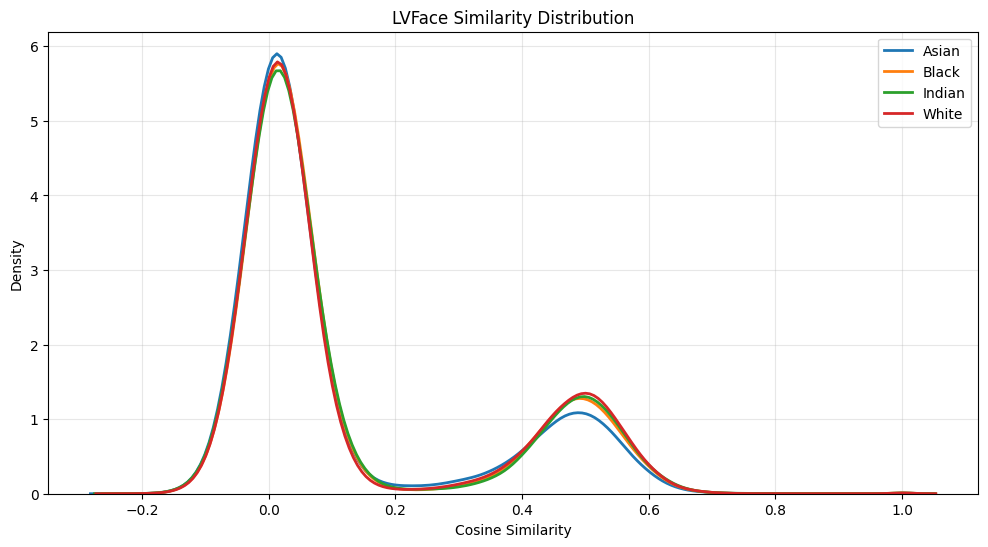

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

groups = ["asian", "black", "indian", "white"]

for group in groups:

    group_scores = df[
        df["att1"].str.contains(group, case=False, na=False)
    ]["cosine_similarity"]

    sns.kdeplot(
        group_scores,
        label=group.capitalize(),
        fill=False,
        linewidth=2
    )

plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("LVFace Similarity Distribution")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [42]:
df["race"] = df["att1"].str.split("_").str[0]

df["gender"] = df["att1"].str.split("_").str[1]

In [43]:
print(df["gender"].value_counts())

gender
females    461950
males      461948
Name: count, dtype: int64


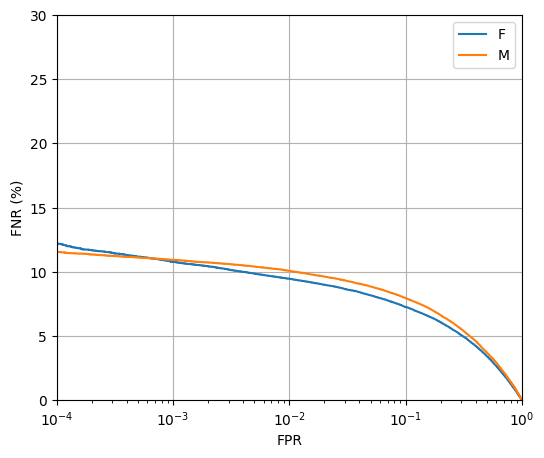

In [53]:
plt.figure(figsize=(6,5))

for gender, label in [
    ("females", "F"),
    ("males", "M")
]:

    subset = df[df["gender"] == gender]

    fpr, fnr = get_det(subset)

    if fpr is not None:
        plt.plot(fpr, fnr, label=label)

plt.xscale("log")
plt.xlabel("FPR")
plt.ylabel("FNR (%)")
plt.xlim(1e-4, 1)
plt.ylim(0, 30)
plt.legend()
plt.grid(True)

plt.show()

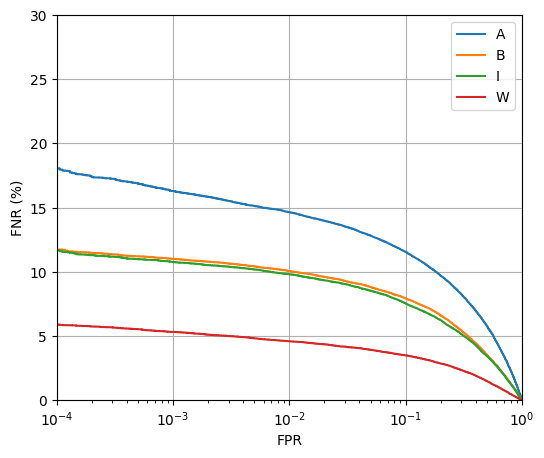

In [52]:
race_labels = {
    "asian":"A",
    "black":"B",
    "indian":"I",
    "white":"W"
}

plt.figure(figsize=(6,5))

for race, short in race_labels.items():

    subset = df[df["race"] == race]

    fpr, fnr = get_det(subset)

    if fpr is not None:
        plt.plot(fpr, fnr, label=short)

plt.xscale("log")
plt.xlabel("FPR")
plt.ylabel("FNR (%)")
plt.xlim(1e-4, 1)
plt.ylim(0, 30)
plt.legend()
plt.grid(True)

plt.show()

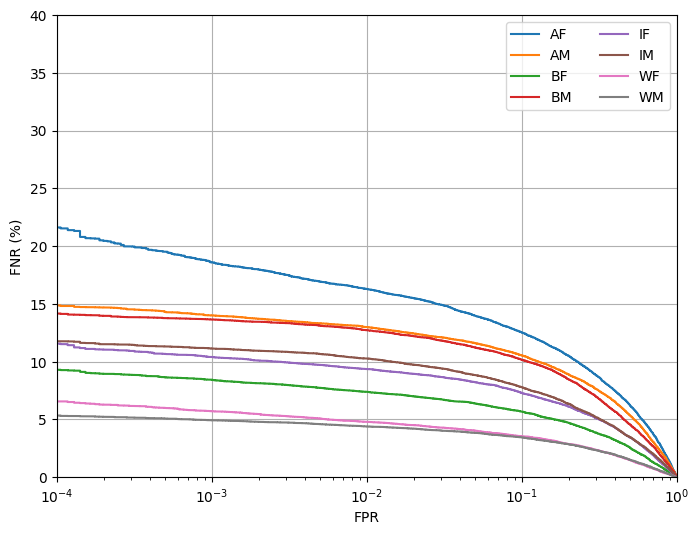

In [51]:
groups = {
    "asian_females":"AF",
    "asian_males":"AM",
    "black_females":"BF",
    "black_males":"BM",
    "indian_females":"IF",
    "indian_males":"IM",
    "white_females":"WF",
    "white_males":"WM"
}

plt.figure(figsize=(8,6))

for group, short in groups.items():

    subset = df[df["att1"] == group]

    fpr, fnr = get_det(subset)

    if fpr is not None:
        plt.plot(fpr, fnr, label=short)

plt.xscale("log")
plt.xlabel("FPR")
plt.ylabel("FNR (%)")
plt.xlim(1e-4, 1)
plt.ylim(0, 40)
plt.legend(ncol=2)
plt.grid(True)

plt.show()